# Mjøsa Navigation Data Processing Pipeline

**Purpose:** Create corrected navigation CSV from Eelume robot 6DOF log data

**Date:** 2024-10-29 (Lake Mjøsa UHI Mission)

**Author:** Erik Liu (NTNU)

---

## 🎯 MAIN OUTPUT FILE

### **`nav_data_merged.csv`** 
This notebook creates ONE main file that you need for georeferencing:

**Location:** `E:\mjosa_complete\data\processed\navigation\nav_data_merged.csv`

**Method:** Constant Velocity Dead Reckoning (0.2 m/s) applied during transect segments

**What it contains:**
- Original GNSS positions when robot is on surface
- Dead-reckoned positions during underwater transect segments (where GNSS fails)

---

## Overview

This notebook processes Eelume robot navigation data through the following steps:

1. **Load .db3 file** → Extract 6DOF pose data to CSV
2. **Extract transects** → Identify time segments for correction
3. **Apply dead reckoning** → Correct positions using constant velocity (0.2 m/s)
4. **Merge corrections** → Replace transect segments with corrected positions
5. **Convert to EIVA** → Format for EIVA software (optional)

All configuration is centralized in `mjosa_code/utils/common/config.py`

---

## Quick Start

**To run the complete pipeline:** Just click **"Run All"** at the top!

The notebook will:
- Load configuration from `config.py`
- Process navigation data through all steps
- Generate validation plots comparing different methods
- Save **`nav_data_merged.csv`** (your main output file)

All functions are in `mjosa_code/utils/` - this notebook just calls them!

## Setup

In [1]:
# Import navigation processing utilities
import sys
from pathlib import Path

# Add gref4hsi root to path (parent of mjosa_code)
notebook_dir = Path().resolve()  # Current notebook directory
gref4hsi_root = notebook_dir.parent.parent.parent  # Go up to gref4hsi root
sys.path.insert(0, str(gref4hsi_root))

print(f"📂 Added to path: {gref4hsi_root}")
print(f"📂 mjosa_code location: {gref4hsi_root / 'mjosa_code'}")

from mjosa_code.utils.common import config
from mjosa_code.utils.nav import nav_processing

print("✅ Imports successful!")
print(f"📦 mjosa_code version: {__import__('mjosa_code').__version__}")

📂 Added to path: C:\Users\Erik Liu\OneDrive - NTNU\PhD\Courses\UHI post processing\havard_repo\from_Leo_usb\gref4hsi
📂 mjosa_code location: C:\Users\Erik Liu\OneDrive - NTNU\PhD\Courses\UHI post processing\havard_repo\from_Leo_usb\gref4hsi\mjosa_code
✅ Imports successful!
📦 mjosa_code version: 1.0.0
✅ Imports successful!
📦 mjosa_code version: 1.0.0


## Configuration

View current configuration settings:

In [2]:
# Reload config modules to get latest changes
import importlib
from mjosa_code.utils.common import config_utils

importlib.reload(config)
importlib.reload(config_utils)

# Display configuration summary
config_utils.print_config_summary()

# Validate configuration
print()
config_utils.validate_config()

MJØSA NAVIGATION PROCESSING CONFIGURATION
Mission Date:        2024-10-29
Mission Duration:    10:10:00 - 13:50:00 UTC
Number of Transects: 7
Origin Point:        (60.8011460°N, 10.7051250°E)
Default DR Method:   constant_velocity
Constant Velocity:   0.2 m/s
Use DVL Data:        True

Input Log File:      E:\mjosa_complete\data\raw\navigation\LOG_2024-10-29_10-13-32.db3
Output Main CSV:     E:\mjosa_complete\data\processed\navigation\nav_data_from_logfile.csv
Output Merged CSV:   E:\mjosa_complete\data\processed\navigation\nav_data_merged.csv
Output EIVA TXT:     E:\mjosa_complete\data\processed\navigation\merged_data_for_EIVA.txt

✅ Configuration validation passed!


True

## Option 1: Run Complete Pipeline (⭐ RECOMMENDED)

**This creates your main output file: `nav_data_merged.csv`**

**Method:** Constant Velocity Dead Reckoning (0.2 m/s)
- Proven reliable for this mission
- Simple and consistent results
- This is what you should use for georeferencing

Run all steps automatically with a single function call:

In [3]:
# ⭐ RUN THIS to create nav_data_merged.csv (your main output file)
# Uses constant velocity dead reckoning (0.2 m/s) - proven reliable method
results = nav_processing.run_complete_pipeline(
    db3_file=None,  # Use config default
    use_dvl=False,  # Use constant velocity (NOT DVL)
    verbose=True,  # Show detailed progress
)

print("\n" + "=" * 80)
print("✅ MAIN OUTPUT FILE CREATED:")
print(f"   📁 {results['merged_csv']}")
print("=" * 80)
print("👉 Use this file for georeferencing your hyperspectral data!")
print("=" * 80)


                    MJØSA NAVIGATION PROCESSING PIPELINE
MJØSA NAVIGATION PROCESSING CONFIGURATION
Mission Date:        2024-10-29
Mission Duration:    10:10:00 - 13:50:00 UTC
Number of Transects: 7
Origin Point:        (60.8011460°N, 10.7051250°E)
Default DR Method:   constant_velocity
Constant Velocity:   0.2 m/s
Use DVL Data:        True

Input Log File:      E:\mjosa_complete\data\raw\navigation\LOG_2024-10-29_10-13-32.db3
Output Main CSV:     E:\mjosa_complete\data\processed\navigation\nav_data_from_logfile.csv
Output Merged CSV:   E:\mjosa_complete\data\processed\navigation\nav_data_merged.csv
Output EIVA TXT:     E:\mjosa_complete\data\processed\navigation\merged_data_for_EIVA.txt

🚀 Starting complete processing pipeline...

STEP 1: Loading .db3 file to CSV
Input:  E:\mjosa_complete\data\raw\navigation\LOG_2024-10-29_10-13-32.db3
Output: E:\mjosa_complete\data\processed\navigation\nav_data_from_logfile.csv
Time:   2024-10-29 10:10:00+00:00 to 2024-10-29 13:50:00+00:00
Duration:

In [4]:
# Display results
print("\n📊 Pipeline Results:")
print(f"   Main CSV:       {results['main_csv']}")
print(f"   Transect CSVs:  {len(results['transect_csvs'])} files")
print(f"   DR CSVs:        {len(results['dr_csvs'])} files")
print(f"   Merged CSV:     {results['merged_csv']}")
print(f"   EIVA TXT:       {results['eiva_txt']}")


📊 Pipeline Results:
   Main CSV:       E:\mjosa_complete\data\processed\navigation\nav_data_from_logfile.csv
   Transect CSVs:  7 files
   DR CSVs:        7 files
   Merged CSV:     E:\mjosa_complete\data\processed\navigation\nav_data_merged.csv
   EIVA TXT:       E:\mjosa_complete\data\processed\navigation\merged_data_for_EIVA.txt


## Option 2: Run Pipeline with DVL Velocity (🔬 EXPERIMENTAL)

**⚠️ This is for comparison/validation only - NOT the main output!**

Alternative method using actual DVL velocity measurements instead of constant 0.2 m/s:
- More complex, less tested
- Use for validation and comparison purposes
- Results may vary depending on DVL data quality

In [ ]:
# 🔬 EXPERIMENTAL: Run with DVL velocity (for comparison only)
# This uses actual DVL measurements instead of constant velocity
# Output files will have "_dvl" suffix so they don't overwrite the main files
results_dvl = nav_processing.run_complete_pipeline(
    db3_file=None,  # Use config default
    use_dvl=True,  # Use DVL velocity measurements
    verbose=True,
)

print("\n" + "=" * 80)
print("✅ DVL OUTPUT FILES CREATED:")
print(f"   📁 Merged CSV: {results_dvl['merged_csv']}")
print(f"   📁 EIVA TXT:   {results_dvl['eiva_txt']}")
print("=" * 80)
print("⚠️  This is an ALTERNATIVE method for comparison.")
print("👉 Use the constant velocity result (Option 1) as your main output!")
print("=" * 80)


                    MJØSA NAVIGATION PROCESSING PIPELINE
MJØSA NAVIGATION PROCESSING CONFIGURATION
Mission Date:        2024-10-29
Mission Duration:    10:10:00 - 13:50:00 UTC
Number of Transects: 7
Origin Point:        (60.8011460°N, 10.7051250°E)
Default DR Method:   constant_velocity
Constant Velocity:   0.2 m/s
Use DVL Data:        True

Input Log File:      E:\mjosa_complete\data\raw\navigation\LOG_2024-10-29_10-13-32.db3
Output Main CSV:     E:\mjosa_complete\data\processed\navigation\nav_data_from_logfile.csv
Output Merged CSV:   E:\mjosa_complete\data\processed\navigation\nav_data_merged.csv
Output EIVA TXT:     E:\mjosa_complete\data\processed\navigation\merged_data_for_EIVA.txt

🚀 Starting complete processing pipeline...

STEP 1: Loading .db3 file to CSV
Input:  E:\mjosa_complete\data\raw\navigation\LOG_2024-10-29_10-13-32.db3
Output: E:\mjosa_complete\data\processed\navigation\nav_data_from_logfile.csv
Time:   2024-10-29 10:10:00+00:00 to 2024-10-29 13:50:00+00:00
Duration:

## Option 3: Run Steps Individually

For more control, run each step separately (commented out for now):

### Step 1: Load .db3 File to CSV

In [ ]:
# Load ROS2 .db3 file and extract 6DOF data
db, analyzer = nav_processing.load_db3_to_csv(
    str(config.LOG_DB3_FILE),
    str(config.MAIN_CSV_FILE),
    config.MISSION_START_TIME,
    config.MISSION_END_TIME,
    verbose=True,
)

STEP 1: Loading .db3 file to CSV
Input:  E:\mjosa_complete\data\raw\navigation\LOG_2024-10-29_10-13-32.db3
Output: E:\mjosa_complete\data\processed\navigation\nav_data_from_logfile.csv
Time:   2024-10-29 10:10:00+00:00 to 2024-10-29 13:50:00+00:00
Duration: 13200.0 seconds

📂 Opening database...
📊 Creating motion analyzer...
💾 Extracting and aligning 6DOF data...
Creating time-aligned CSV...
Common time range: 1730196822.8 to 1730209799.9
Reference time grid: 276802 points
Common time range: 1730196822.8 to 1730209799.9
Reference time grid: 276802 points
  ⚠️  altitude [m]: 42651 NaN values (15.4%)
Removed 42651 rows with NaN values
Final dataset: 234151 rows
  ⚠️  altitude [m]: 42651 NaN values (15.4%)
Removed 42651 rows with NaN values
Final dataset: 234151 rows
✅ Saved aligned CSV to: E:\mjosa_complete\data\processed\navigation\nav_data_from_logfile.csv
✅ CSV created successfully!
⏱️  Time elapsed: 12.80 seconds
✅ Saved aligned CSV to: E:\mjosa_complete\data\processed\navigation\nav

### Step 2: Extract Transect Segments

In [ ]:
# Extract time-specific transect segments
transect_csvs = nav_processing.extract_transect_segments(
    str(config.MAIN_CSV_FILE),
    config.TRANSECT_TIME_INTERVALS,
    str(config.PROCESSED_NAVIGATION_DIR),
    analyzer,
    verbose=True,
)


STEP 2: Extracting Transect Segments
Input:  E:\mjosa_complete\data\processed\navigation\nav_data_from_logfile.csv
Output: E:\mjosa_complete\data\processed\navigation
Number of transects: 7

📂 Extracting transect CSV files...
✅ Transect 10:50:51-10:59:06: 10709 points (yaw range: 179.4° to 180.6°)
   📁 Saved to: E:\mjosa_complete\data\processed\navigation\105051\nav_data_105051.csv

✅ Transect 11:23:50-11:25:04: 1688 points (yaw range: 179.2° to 180.3°)
   📁 Saved to: E:\mjosa_complete\data\processed\navigation\112350\nav_data_112350.csv

✅ Transect 11:26:32-11:31:35: 6776 points (yaw range: 179.4° to 180.4°)
   📁 Saved to: E:\mjosa_complete\data\processed\navigation\112632\nav_data_112632.csv

✅ Transect 10:50:51-10:59:06: 10709 points (yaw range: 179.4° to 180.6°)
   📁 Saved to: E:\mjosa_complete\data\processed\navigation\105051\nav_data_105051.csv

✅ Transect 11:23:50-11:25:04: 1688 points (yaw range: 179.2° to 180.3°)
   📁 Saved to: E:\mjosa_complete\data\processed\navigation\1123

### Step 3: Apply Dead Reckoning

Choose either constant velocity or DVL-based method:

In [ ]:
# Method A: Constant velocity (proven reliable)
dr_csvs = nav_processing.apply_constant_velocity_dr(
    transect_csvs,
    analyzer,
    output_suffix="_dr",
    adjust_speed=config.ADJUST_SPEED_TO_HIT_END,
    verbose=True,
)


STEP 3A: Constant Velocity Dead Reckoning
Method: Constant bearing from start→end, constant speed
Speed:  0.2 m/s
Adjust: True
Files:  7

📁 1. Processing: nav_data_105051.csv
[DR] nav_data_105051.csv → nav_data_105051_dr.csv (-179.41°, 0.192 m/s)
   ✅ Created: nav_data_105051_dr.csv
      Points: 10709 → 10709

📁 2. Processing: nav_data_112350.csv
[DR] nav_data_112350.csv → nav_data_112350_dr.csv (-179.53°, 0.196 m/s)
   ✅ Created: nav_data_112350_dr.csv
      Points: 1688 → 1688

📁 3. Processing: nav_data_112632.csv
[DR] nav_data_105051.csv → nav_data_105051_dr.csv (-179.41°, 0.192 m/s)
   ✅ Created: nav_data_105051_dr.csv
      Points: 10709 → 10709

📁 2. Processing: nav_data_112350.csv
[DR] nav_data_112350.csv → nav_data_112350_dr.csv (-179.53°, 0.196 m/s)
   ✅ Created: nav_data_112350_dr.csv
      Points: 1688 → 1688

📁 3. Processing: nav_data_112632.csv
[DR] nav_data_112632.csv → nav_data_112632_dr.csv (-178.42°, 0.197 m/s)
   ✅ Created: nav_data_112632_dr.csv
      Points: 6776 

In [ ]:
# Method B: DVL velocity (alternative)
dr_csvs_dvl = nav_processing.apply_dvl_velocity_dr(
    transect_csvs,
    analyzer,
    output_suffix="_dr_dvl_v2",
    adjust_speed=False,
    verbose=True,
)


STEP 3B: DVL Velocity Dead Reckoning
Method: Constant bearing from start→end, actual DVL speeds
Fallback: Constant 0.2 m/s if DVL unavailable
Adjust: False
Files:  7

📁 1. Processing: nav_data_105051.csv
🚀 DVL dead reckoning (constant heading): nav_data_105051.csv
   🧭 Constant bearing: -179.41°
   📊 DVL speed range: 0.003 to 0.238 m/s
   📊 Average DVL speed: 0.195 m/s
   📊 DVL speed range: 0.003 to 0.238 m/s
   📊 Average DVL speed: 0.195 m/s
   ✅ DVL DR complete: -179.41°, avg speed 0.195 m/s
   📏 Original distance: 95.1 m
   📏 DR distance: 96.7 m
   💾 Saved: nav_data_105051_dr_dvl_v2.csv
   ✅ Created: nav_data_105051_dr_dvl_v2.csv (0.66s)
      Avg DVL speed: 0.195 m/s (vs 0.2 m/s constant)

📁 2. Processing: nav_data_112350.csv
🚀 DVL dead reckoning (constant heading): nav_data_112350.csv
   🧭 Constant bearing: -179.53°
   ✅ DVL DR complete: -179.41°, avg speed 0.195 m/s
   📏 Original distance: 95.1 m
   📏 DR distance: 96.7 m
   💾 Saved: nav_data_105051_dr_dvl_v2.csv
   ✅ Created: na

### Step 4: Merge Corrected Transects

In [ ]:
# Merge corrected transects back into main CSV
merged_path = nav_processing.merge_transect_fixes(
    str(config.MAIN_CSV_FILE),
    dr_csvs,  # Use dr_csvs_dvl for DVL method
    str(config.MERGED_CSV_FILE),
    verbose=True,
)


STEP 4: Merging Corrected Transects
Main file:     E:\mjosa_complete\data\processed\navigation\nav_data_from_logfile.csv
Transect DRs:  7
Output:        E:\mjosa_complete\data\processed\navigation\nav_data_merged.csv

📂 Loading main navigation file...
   Original: 234151 data points
   ✅ 1. nav_data_105051_dr.csv: Replaced 10709 points, added 10709
   ✅ 2. nav_data_112350_dr.csv: Replaced 1688 points, added 1688
   ✅ 3. nav_data_112632_dr.csv: Replaced 6776 points, added 6776
   Original: 234151 data points
   ✅ 1. nav_data_105051_dr.csv: Replaced 10709 points, added 10709
   ✅ 2. nav_data_112350_dr.csv: Replaced 1688 points, added 1688
   ✅ 3. nav_data_112632_dr.csv: Replaced 6776 points, added 6776
   ✅ 4. nav_data_115927_dr.csv: Replaced 11861 points, added 11861
   ✅ 5. nav_data_122509_dr.csv: Replaced 11549 points, added 11549
   ✅ 6. nav_data_125858_dr.csv: Replaced 10497 points, added 10497
   ✅ 7. nav_data_131005_dr.csv: Replaced 4054 points, added 4054

🔄 Sorting by timestamp

### Step 5: Convert to EIVA Format

In [ ]:
# Convert merged CSV to EIVA-compatible text format
eiva_path = nav_processing.convert_to_eiva_format(
    str(config.MERGED_CSV_FILE), str(config.EIVA_TXT_FILE), verbose=True
)


STEP 5: Converting to EIVA Format
Input:  E:\mjosa_complete\data\processed\navigation\nav_data_merged.csv
Output: E:\mjosa_complete\data\processed\navigation\merged_data_for_EIVA.txt

📂 Reading CSV file...
🔄 Converting timestamps...
📝 Formatting EIVA output...
🔄 Converting timestamps...
📝 Formatting EIVA output...
💾 Writing EIVA text file...
💾 Writing EIVA text file...

✅ EIVA file created successfully!
   Data points: 234151
   Output file: E:\mjosa_complete\data\processed\navigation\merged_data_for_EIVA.txt
⏱️  Time elapsed: 33.04 seconds

First few lines of output:
   Date     Time          Lat [deg]         Long [deg]        Depth [Meter]
   20241029 101342.842664 60.80110898827765 10.70525895701778 110.7889106455
   20241029 101342.866320 60.80110898648739 10.70525895053506 110.7889173162
   20241029 101342.893757 60.80110898441102 10.70525894301639 110.7944052777

✅ EIVA file created successfully!
   Data points: 234151
   Output file: E:\mjosa_complete\data\processed\navigation

## Quick Data Inspection

In [ ]:
# Load and inspect final merged CSV
import pandas as pd

df_merged = pd.read_csv(config.MERGED_CSV_FILE)

print("\n📊 Final Merged CSV Statistics:")
print(f"   Total points: {len(df_merged)}")
print(
    f"   Time range:   {df_merged['timestamp [unix epoch s]'].min():.2f} to {df_merged['timestamp [unix epoch s]'].max():.2f}"
)
print(
    f"   Lat range:    {df_merged['latitude [deg]'].min():.6f} to {df_merged['latitude [deg]'].max():.6f}"
)
print(
    f"   Lon range:    {df_merged['longitude [deg]'].min():.6f} to {df_merged['longitude [deg]'].max():.6f}"
)
print(
    f"   Depth range:  {df_merged['depth [m]'].min():.2f} to {df_merged['depth [m]'].max():.2f} m"
)

# Display first few rows
print("\n📝 First 5 rows:")
df_merged.head()


📊 Final Merged CSV Statistics:
   Total points: 234151
   Time range:   1730196822.84 to 1730207761.97
   Lat range:    60.799772 to 60.801592
   Lon range:    10.705084 to 10.706555
   Depth range:  91.50 to 135.31 m

📝 First 5 rows:


,timestamp [unix epoch s],latitude [deg],longitude [deg],depth [m],roll [deg],pitch [deg],yaw [deg],altitude [m],latitude [deg] (orig),longitude [deg] (orig),dr_speed [m/s]
0,1.730197e+09,60.801109,10.705259,110.788911,-1.675687,-10.001676,295.246290,11.499957,NaN,NaN,NaN
1,1.730197e+09,60.801109,10.705259,110.788917,-1.685247,-10.020624,295.241885,11.501132,NaN,NaN,NaN
2,1.730197e+09,60.801109,10.705259,110.794405,-1.696334,-10.042600,295.236776,11.502495,NaN,NaN,NaN
3,1.730197e+09,60.801109,10.705259,110.798876,-1.704558,-10.061631,295.231732,11.503605,NaN,NaN,NaN
4,1.730197e+09,60.801109,10.705259,110.798878,-1.713900,-10.083250,295.226002,11.504867,NaN,NaN,NaN


## Summary

✅ Navigation processing complete!

---

## 🎯 MAIN OUTPUT FILE - THIS IS WHAT YOU NEED:

### **`nav_data_merged.csv`** 
**Location:** `E:\mjosa_complete\data\processed\navigation\nav_data_merged.csv`

**This is THE final corrected navigation file for georeferencing your hyperspectral data!**

**Method used:** 
- **Constant Velocity Dead Reckoning (0.2 m/s)** - Proven reliable method
- GNSS positions are replaced with dead-reckoned positions during transect segments
- Outside transects: Original GNSS positions are kept

---

## 📁 All Output Files Explained:

| File | Purpose | Use This For |
|------|---------|--------------|
| **`nav_data_merged.csv`** | ⭐ **MAIN OUTPUT** - Constant velocity DR | **Georeferencing HSI data** |
| `nav_data_merged_dvl.csv` | Alternative - DVL velocity DR | Comparison/validation |
| `nav_data_from_logfile.csv` | Raw GNSS from .db3 file (before correction) | Reference/comparison |
| `merged_data_for_EIVA.txt` | Main merged in EIVA format | Import to EIVA software |
| `merged_data_for_EIVA_dvl.txt` | DVL merged in EIVA format | Import to EIVA (alternative) |
| `105051/nav_data_105051_dr.csv` | Dead-reckoned transect 1 (constant velocity) | Intermediate/validation |
| `105051/nav_data_105051_dr_dvl_v2.csv` | Dead-reckoned transect 1 (DVL velocity) | Intermediate/validation |
| ... (9 transects × 2 methods) | Individual corrected segments | Intermediate/validation |

---

## 🔍 What Does "Merged" Mean?

The **merged CSV** combines:
1. **Original GNSS data** - Used when robot is NOT in a transect
2. **Dead-reckoned positions** - Used DURING the 9 transect time intervals (where GNSS is unreliable underwater)

**Why do we do this?**
- GNSS works fine on the surface → Keep original positions
- GNSS fails underwater during transects → Replace with dead-reckoning

**Two versions:**
- `nav_data_merged.csv` - Uses constant velocity (0.2 m/s) ⭐ **USE THIS**
- `nav_data_merged_dvl.csv` - Uses DVL velocity measurements (experimental)

---

## 🚀 Next Steps:

1. **Use `nav_data_merged.csv` for georeferencing** your hyperspectral imagery
2. Optional: Compare with `nav_data_merged_dvl.csv` to validate results
3. Optional: Import `merged_data_for_EIVA.txt` into EIVA for visualization
4. Optional: Check validation plots below to verify accuracy

## Validation and Visualization

Now let's validate the results by plotting different approaches and comparing them.

### 1. Load LogData for Visualization

First, we need to import the LogData class from the original notebook to enable plotting.

In [ ]:
# Import plotting utilities
from mjosa_code.utils.nav import plotting

print("✅ Plotting utilities loaded successfully!")

✅ Plotting utilities loaded successfully!


### 2. Compare All Three Approaches (Validation)

Compare original GNSS positions, constant velocity DR (⭐ your main method), and DVL-based DR (experimental).

This plot shows you WHY we need dead reckoning during transects.


📊 Now let's compare all three approaches:
   🔵 Original: Simple extraction from main CSV (real GNSS positions)
   🟠 _dr: Constant velocity dead reckoning
   🟢 _dr_dvl: DVL velocity dead reckoning


🎯 Plotting 21 files for comparison...


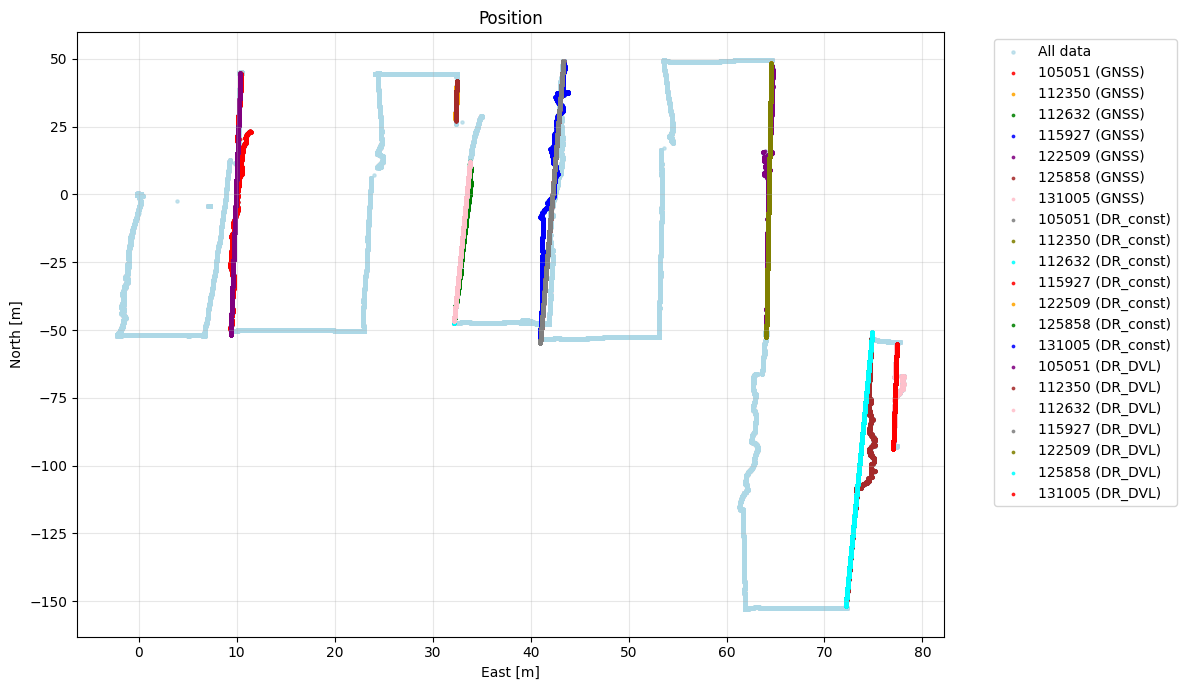

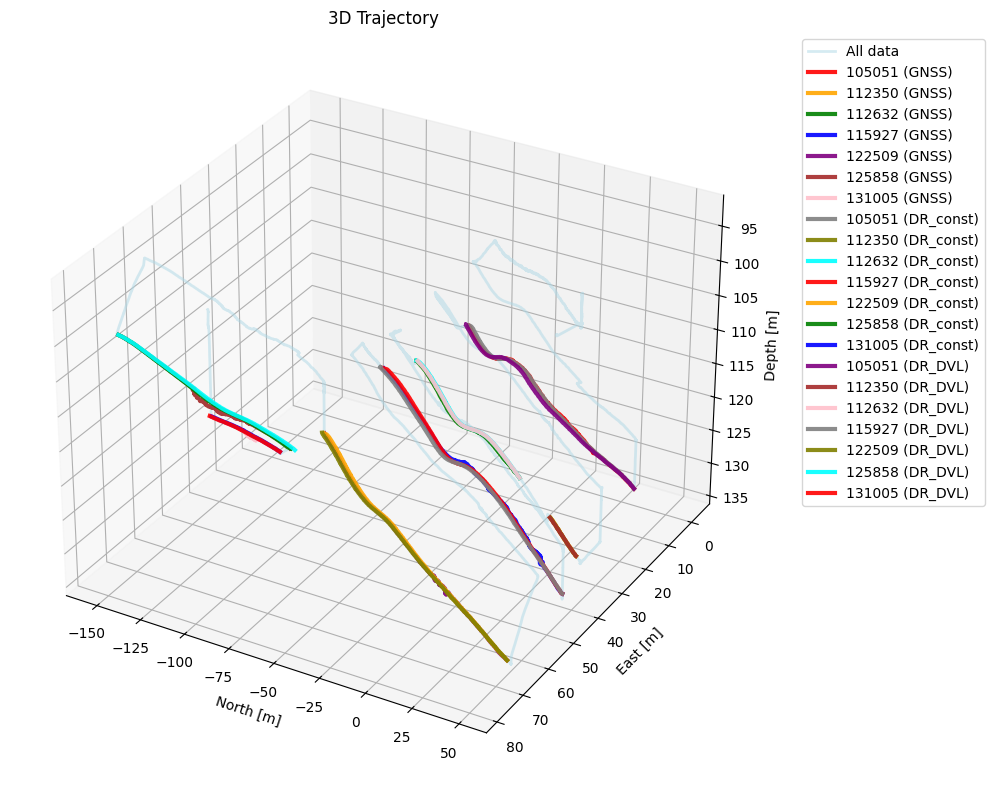


📊 Plotting DOF time series comparisons...


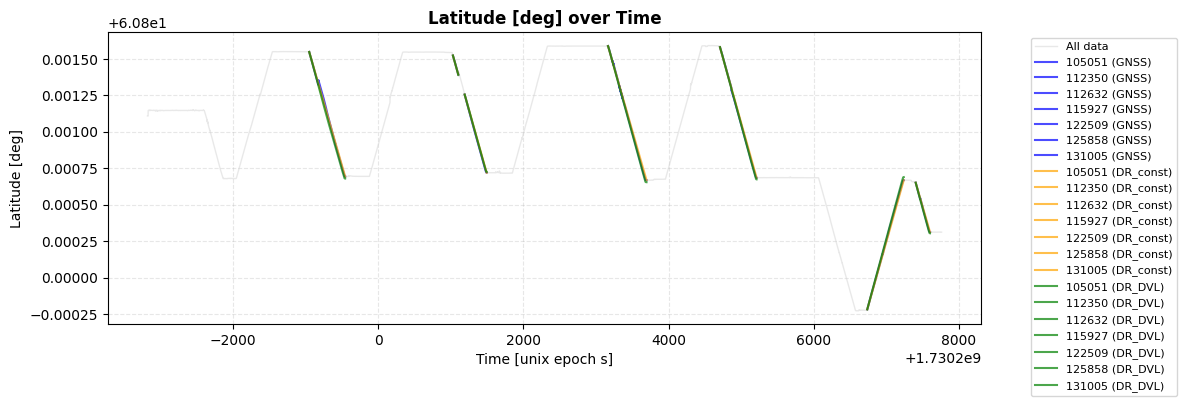

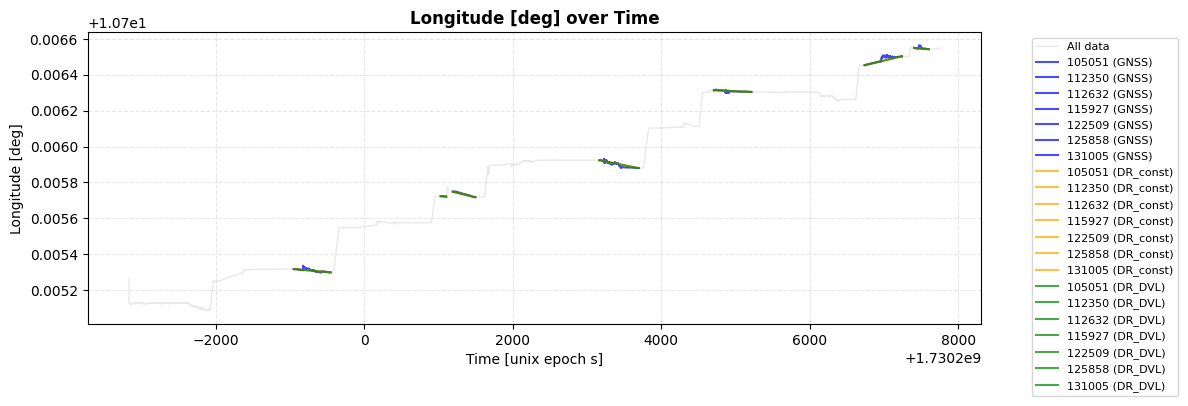

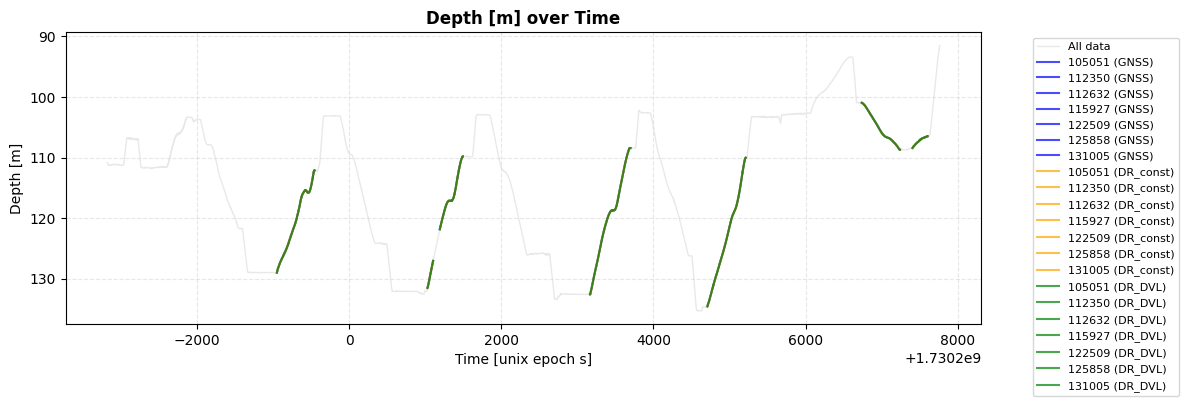

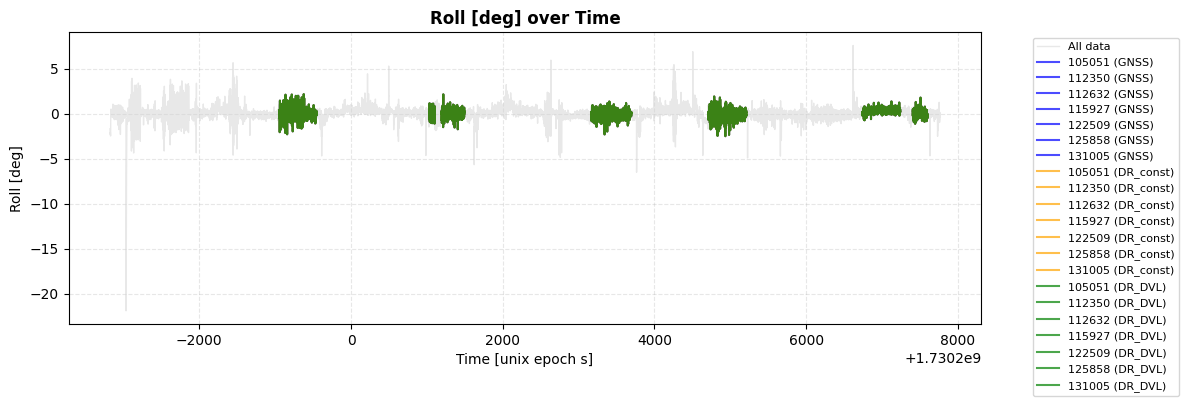

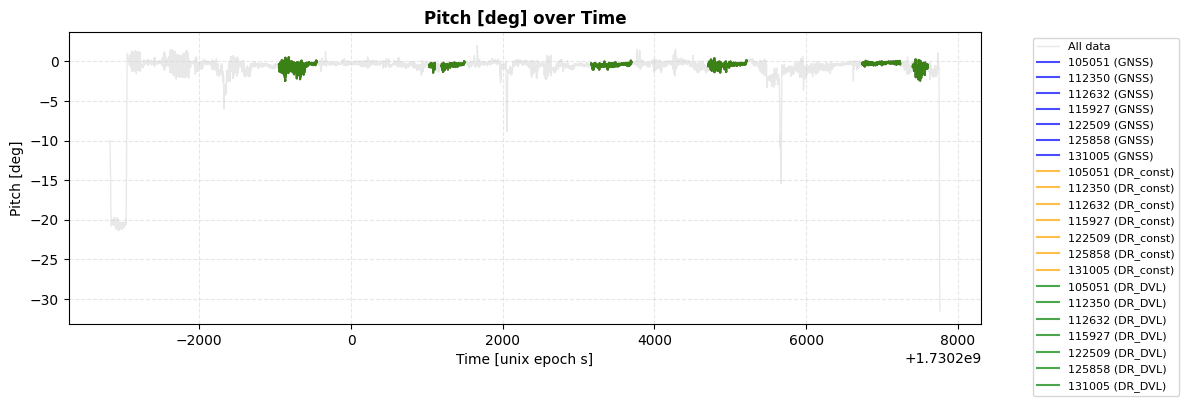

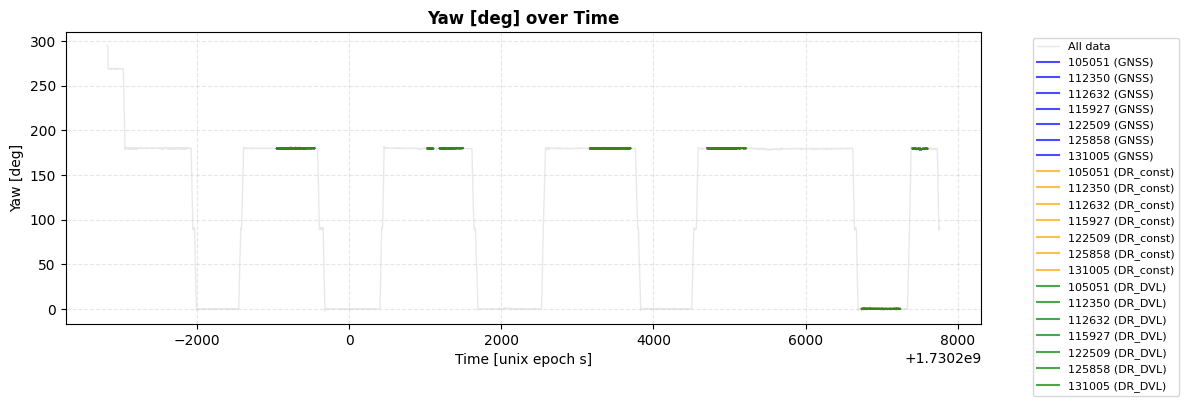

✅ DOF time series plots complete!


In [ ]:
# Compare all three approaches: GNSS, constant velocity DR, and DVL DR
plotting.plot_all_methods_comparison(
    str(config.MAIN_CSV_FILE),
    transect_csvs,
    dr_csvs,
    dr_csvs_dvl,
    config.TRANSECT_TIME_INTERVALS,
    config.MJOSA_ORIGIN,
)

### 3. Plot Merged Navigation Data

View the final merged navigation file with all corrections applied.

📊 Plotting merged navigation data with all corrections applied...
   File: E:\mjosa_complete\data\processed\navigation\nav_data_merged.csv



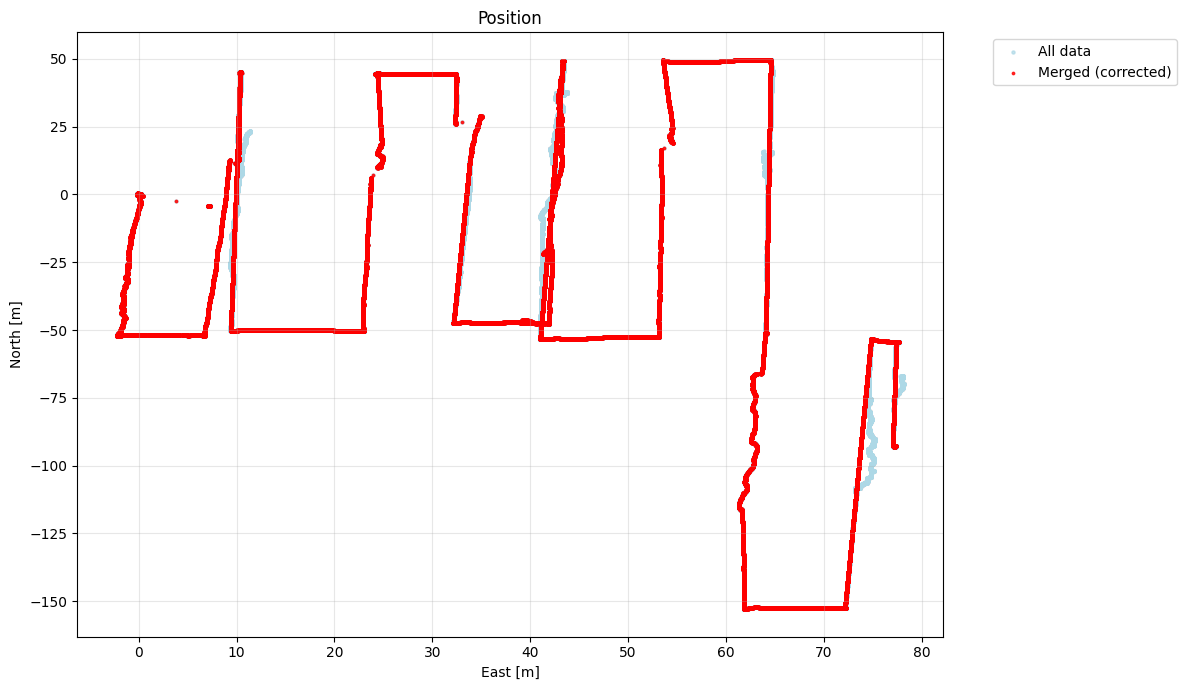

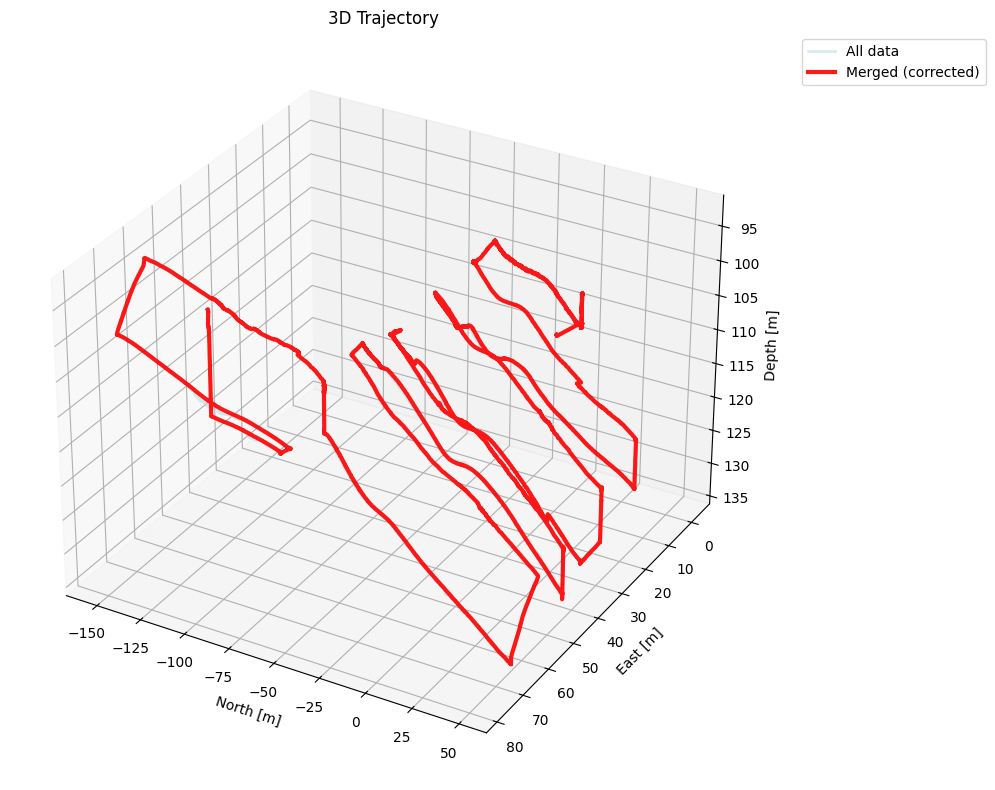

In [ ]:
# Plot the merged navigation data with all corrections applied
plotting.plot_merged_data(
    str(config.MAIN_CSV_FILE),
    merged_path,
    config.MJOSA_ORIGIN,
)

### 4. DVL Velocity Plots

Visualize DVL velocity data for the transect intervals.

📊 Plotting DVL velocity data...
   Transects: 7

🔹 Full mission DVL velocity with highlighted transects:


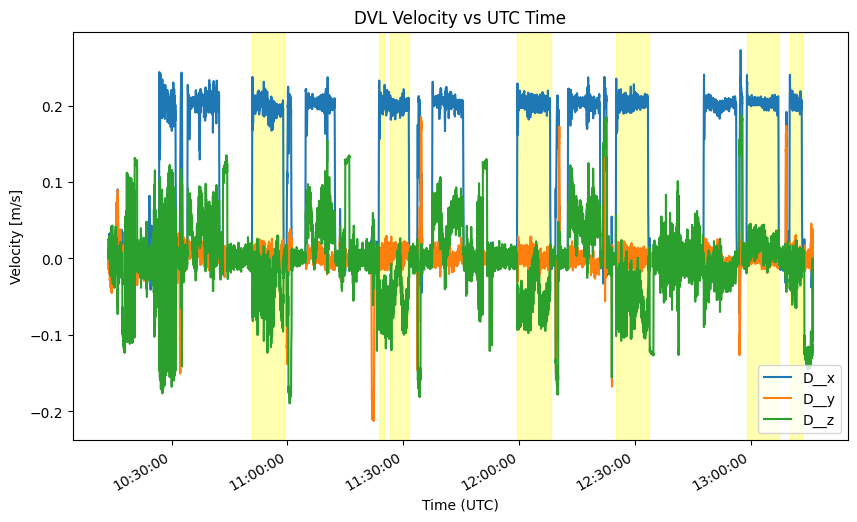


🔹 Individual transect DVL velocity plots:


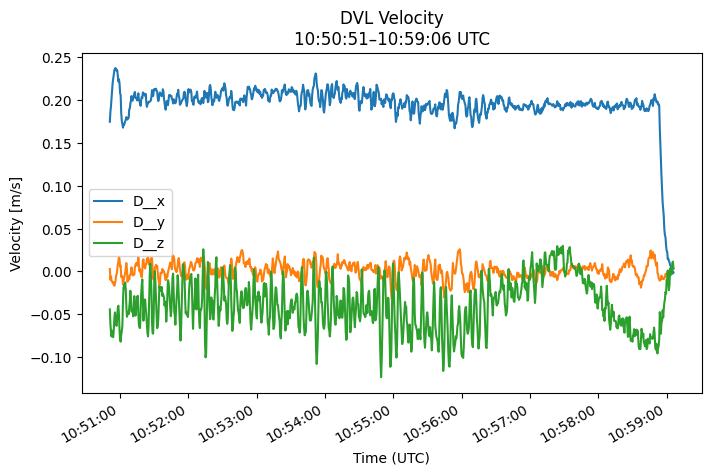

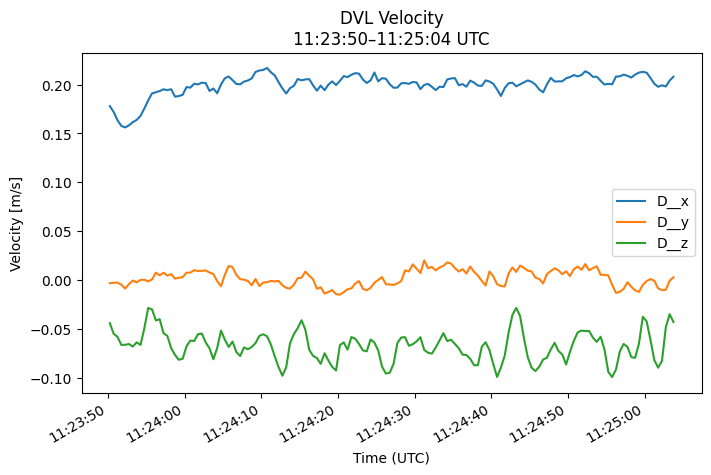

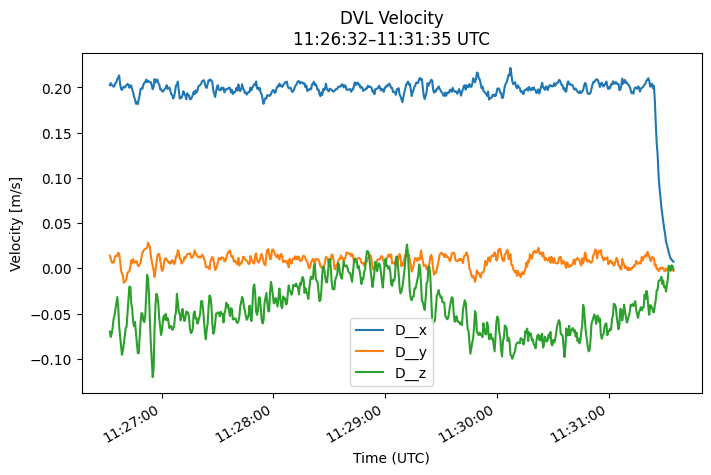

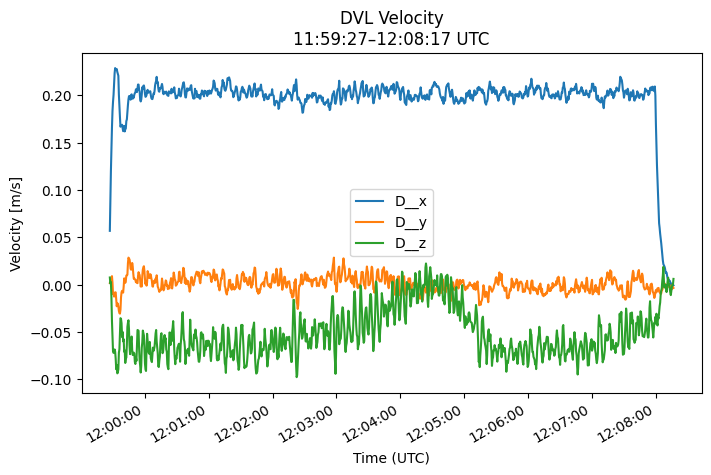

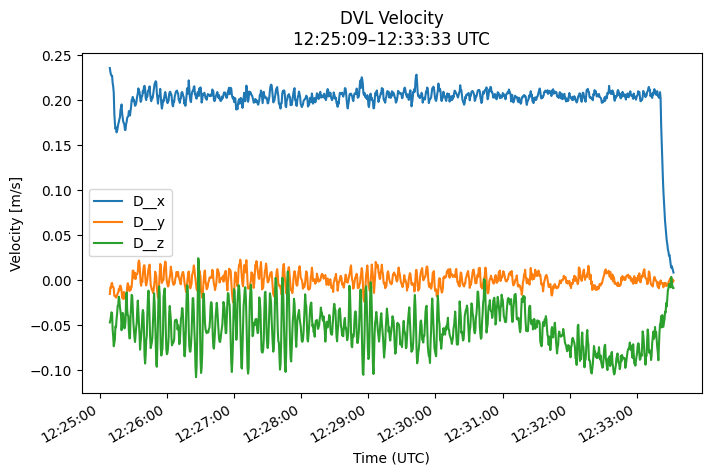

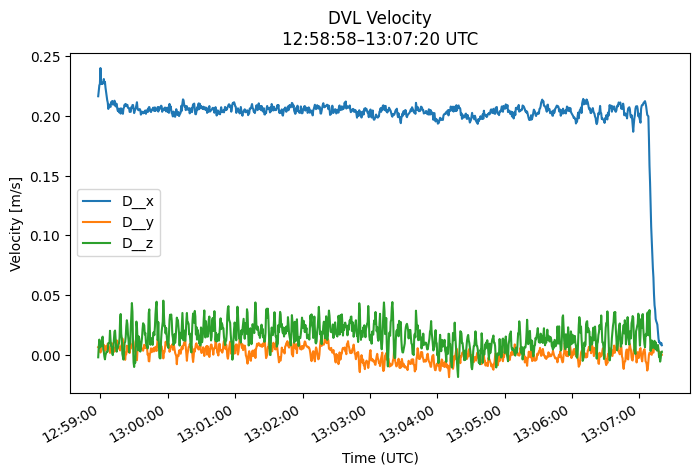

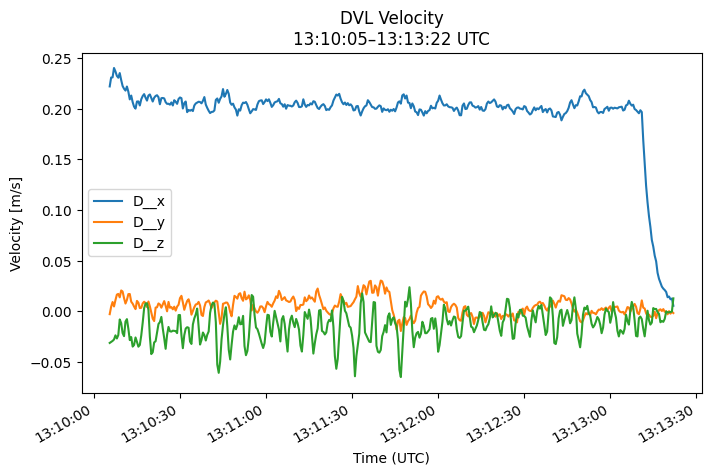

In [ ]:
# Plot DVL velocity data with highlighted transect intervals
plotting.plot_dvl_velocities(
    analyzer,
    config.TRANSECT_TIME_INTERVALS,  # Use string version for analyzer
)

### 5. Quantitative Accuracy Comparison

Calculate endpoint errors for each dead reckoning method.

In [ ]:
# 🔍 DETAILED ANALYSIS: Compare the Methods Quantitatively
plotting.calculate_endpoint_errors(
    transect_csvs,
    dr_csvs,
    dr_csvs_dvl,
    config.MJOSA_ORIGIN,
    config.CONSTANT_VELOCITY_M_S,
)


🔍 Detailed comparison of dead reckoning accuracy...
   Comparing end positions: how close does each DR method get to real GNSS end position?

📊 Endpoint accuracy comparison:
   (How far does each DR method end up from the real GNSS endpoint?)

🎯 Transect 105051:
   🟠 Constant velocity DR error: 0.0 m
   🟢 DVL DR error: 1.5 m
      📊 DVL avg speed: 0.195 m/s (vs 0.2 m/s constant)

🎯 Transect 112350:
   🟠 Constant velocity DR error: 0.0 m
   🟢 DVL DR error: 0.3 m
      📊 DVL avg speed: 0.200 m/s (vs 0.2 m/s constant)

🎯 Transect 112632:
   🟠 Constant velocity DR error: 0.0 m
   🟢 DVL DR error: 0.7 m
      📊 DVL avg speed: 0.195 m/s (vs 0.2 m/s constant)

🎯 Transect 115927:
   🟠 Constant velocity DR error: 0.0 m
   🟢 DVL DR error: 0.3 m
      📊 DVL avg speed: 0.200 m/s (vs 0.2 m/s constant)

🎯 Transect 112632:
   🟠 Constant velocity DR error: 0.0 m
   🟢 DVL DR error: 0.7 m
      📊 DVL avg speed: 0.195 m/s (vs 0.2 m/s constant)

🎯 Transect 115927:
   🟠 Constant velocity DR error: 0.0 m
  

---

# 🎯 FINAL SUMMARY - YOUR OUTPUT FILES

## Main File to Use for Georeferencing:

```
📁 nav_data_merged.csv  ⭐ USE THIS ONE
```

**Full path:** `E:\mjosa_complete\data\processed\navigation\nav_data_merged.csv`

**Method used:** Constant Velocity Dead Reckoning (0.2 m/s)

**What's inside:**
- Original GNSS positions (when robot is on surface)
- Dead-reckoned positions (during 9 underwater transect segments)
- All 6DOF data: lat, lon, depth, roll, pitch, yaw, altitude

---

## Alternative DVL File (For Comparison):

```
📁 nav_data_merged_dvl.csv  🔬 EXPERIMENTAL
```

**Full path:** `E:\mjosa_complete\data\processed\navigation\nav_data_merged_dvl.csv`

**Method used:** DVL Velocity Dead Reckoning (variable velocity from DVL sensor)

**Use this for:** Validation and comparison only, not as primary georeferencing input

---

## Quick Reference:

| What You Need | File Name | Location |
|---------------|-----------|----------|
| **⭐ Main navigation for georeferencing** | `nav_data_merged.csv` | `processed/navigation/` |
| Alternative DVL method (comparison) | `nav_data_merged_dvl.csv` | `processed/navigation/` |
| EIVA format (constant velocity) | `merged_data_for_EIVA.txt` | `processed/navigation/` |
| EIVA format (DVL) | `merged_data_for_EIVA_dvl.txt` | `processed/navigation/` |
| Original GNSS (before correction) | `nav_data_from_logfile.csv` | `processed/navigation/` |

---

## ✅ Processing Complete!

You now have TWO versions of corrected navigation data:
1. **`nav_data_merged.csv`** - Constant velocity (recommended)
2. **`nav_data_merged_dvl.csv`** - DVL velocity (experimental)

**Next step:** Use `nav_data_merged.csv` in your georeferencing pipeline.

---

# 📊 PUBLICATION-READY PLOT

## Highlighted Transect Comparison - 2D Position Plot

In [1]:
# ⚡ QUICK LOAD: Run this cell to load data without running the entire pipeline
# Use this when you just want to regenerate plots with different settings

import sys
from pathlib import Path
import glob

# Setup paths
notebook_dir = Path().resolve()
gref4hsi_root = notebook_dir.parent.parent.parent
sys.path.insert(0, str(gref4hsi_root))

from mjosa_code.utils.common import config
from mjosa_code.utils.nav import plotting

# Find all DR CSV files (constant velocity corrected transects)
dr_csvs = sorted(
    glob.glob(str(config.PROCESSED_NAVIGATION_DIR / "*" / "nav_data_*_dr.csv"))
)

print(f"✅ Quick load complete!")
print(f"   Found {len(dr_csvs)} DR-corrected transect files")
print(f"   Origin: ({config.MJOSA_ORIGIN[0]:.7f}°N, {config.MJOSA_ORIGIN[1]:.7f}°E)")
print(f"\n👉 Now run the next cell to generate the plot!")

✅ Quick load complete!
   Found 7 DR-corrected transect files
   Origin: (60.8011460°N, 10.7051250°E)

👉 Now run the next cell to generate the plot!


📊 Creating publication-ready plot with highlighted transects...

   Legend:
   🔴 Red:    Transect A (4th transect at 11:59:27)
   🔵 Blue:   Transect B (6th transect at 12:58:58)
   🟠 Orange: Other transects


📊 Creating 2D position plot with highlighted transects...
   Origin: (60.8011460°N, 10.7051250°E)
   Highlighting 2 transects

   ✅ Transect A: 11861 points, color=red
   ✅ Transect B: 10497 points, color=blue
   ✅ Transect A: 11861 points, color=red
   ✅ Transect B: 10497 points, color=blue


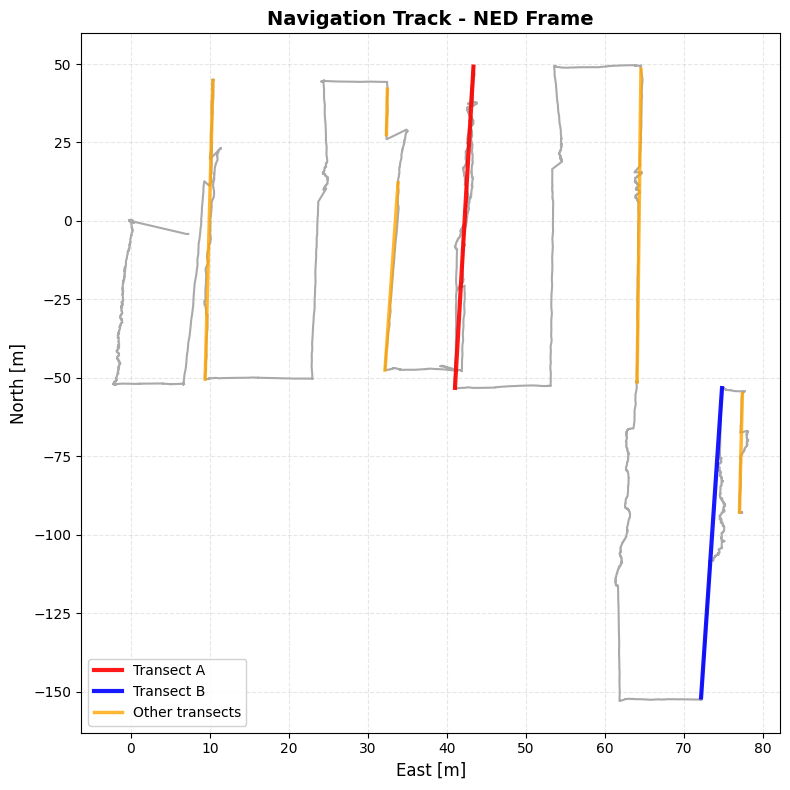


✅ Plot complete!
   Total DR transects: 7 (5 orange + 2 highlighted)


In [2]:
# 🎯 Publication-ready plot with highlighted transects
# This creates a 2D plot in NED frame showing:
#   - Grey: Unfiltered GNSS baseline (no legend entry)
#   - Orange: Other DR corrected transects
#   - Red: Transect A (4th transect - 11:59:27)
#   - Blue: Transect B (6th transect - 12:58:58)

print("📊 Creating publication-ready plot with highlighted transects...")
print()
print("   Legend:")
print("   🔴 Red:    Transect A (4th transect at 11:59:27)")
print("   🔵 Blue:   Transect B (6th transect at 12:58:58)")
print("   🟠 Orange: Other transects")
print()

# Define which transects to highlight
# Index 3 = 4th transect (11:59:27) = Transect A
# Index 5 = 6th transect (12:58:58) = Transect B
highlight_indices = [3, 5]
highlight_labels = ["Transect A", "Transect B"]
highlight_colors = ["red", "blue"]

# Call the plotting function
plotting.plot_highlighted_transects_2d(
    main_csv_path=str(config.MAIN_CSV_FILE),
    dr_csv_paths=dr_csvs,  # All DR constant velocity corrected transects
    highlight_indices=highlight_indices,
    highlight_labels=highlight_labels,
    highlight_colors=highlight_colors,
    origin=config.MJOSA_ORIGIN,
    figsize=(8, 8),  # Figure size in inches
    aspect_ratio="auto",  # "equal"=true scale, "auto"=independent axis scaling
    xlim=None,  # East axis limits: None=auto, or (min, max) e.g., (-10, 100)
    ylim=None,  # North axis limits: None=auto, or (min, max) e.g., (-150, 50)
)